# Scenario Comparison Analysis

In [39]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

### Configuration

In [40]:
base_config_name = "germany_base"
cluster = "450"
home = "/home/lucakristin/Desktop/my_pypsa"

---
# Building networks

Build the base network without transmission projects (with 450 clusters and from the `germany_base.yaml` file)

```bash
# Build the network (dry run)
snakemake -n --cores 6 "resources/germany_base/networks/base_s_450_elec_.nc" --configfile config/config.germany_base.yaml

# Solve the base network -> for line loads
snakemake -n -call solve_elec_networks --configfile config/config.germany_base.yaml
```

## 2. Create scenario network 

In [41]:
scenario_config_name ="germany_scenario_2"
scenario_config_dir = f"{home}/pypsa-eur/config/scenario_configs"
scenario_config_path = f"{scenario_config_dir}/{scenario_config_name}.json"

In [42]:
# First, ensure the scenario is created by running the script.
# This modifies the base network and saves it as the scenario network.
!python ../create_germany_scenario.py --scenario-config-file {scenario_config_path} --home {home}

Loading scenario config from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/scenario_configs/germany_scenario_2.json
Home directory set to: /home/lucakristin/Desktop/my_pypsa
Loading base network from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/resources/germany_base/networks/base_s_450_elec_.nc
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
--- Applying modifications ---
Modifying offshore capacity by a factor of 1
Modifying fossil fuel capacity by a factor of 0.1 for generators south of latitude 54.73 (100% quantile).
Found 1077 fossil fuel generators in the south to modify.
Base fossil fuel capacity in the south: 821117.75 MW
Total modified fossil fuel capacity in the south: 8211.18 MW
Modifying onshore capacity by a factor of 0.5
Exporting scenario network to: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/resources/germany_s

## 3. Load unsolved networks to see modifications

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


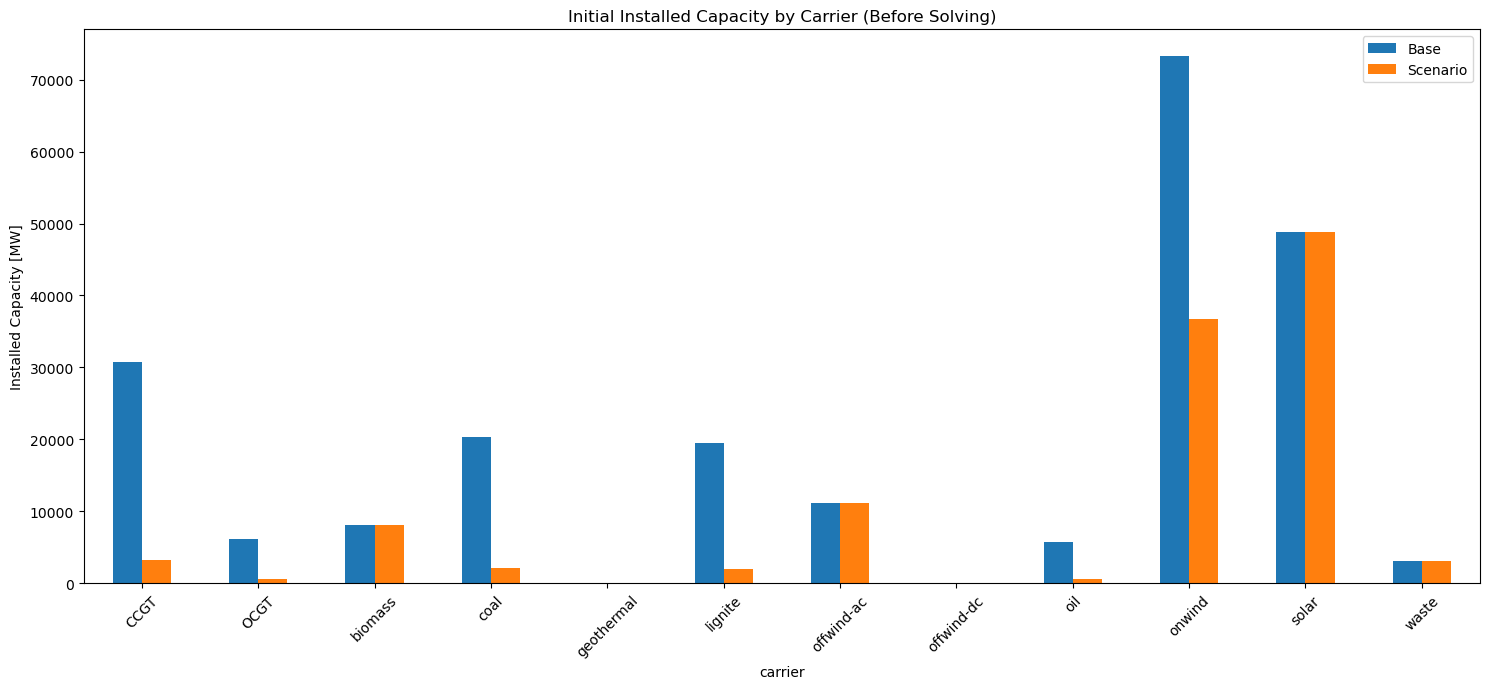

In [45]:
# --- Load Scenario Network ---
scenario_network_path_unsolved = f"{home}/pypsa-eur/resources/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario_unsolved = pypsa.Network(scenario_network_path_unsolved, name="Scenario Network")

# Load the unsolved base network to compare initial capacities
base_network_path_unsolved = f"{home}/pypsa-eur/resources/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base_unsolved = pypsa.Network(base_network_path_unsolved)

p_nom_base = n_base_unsolved.generators.groupby("carrier").p_nom.sum()
p_nom_scenario = n_scenario_unsolved.generators.groupby("carrier").p_nom.sum()

df = pd.DataFrame({
    "Base": p_nom_base,
    "Scenario": p_nom_scenario
}).dropna()

df.plot(kind="bar", figsize=(15, 7), rot=45)
plt.ylabel("Installed Capacity [MW]")
plt.title("Initial Installed Capacity by Carrier (Before Solving)")
plt.tight_layout()
plt.show()

---
# Solving networks

## 1. Check if config.yaml exists before solving 

In [46]:
# Check that a matching scenario config file exists before creating the network.
scenario_yaml_path = f"{home}/pypsa-eur/config/config.{scenario_config_name}.yaml"
if not os.path.isfile(scenario_yaml_path):
    raise FileNotFoundError(
        f"Missing scenario config file: {scenario_yaml_path}\n"
        f"Expected a file named config.{scenario_config_name}.yaml in pypsa-eur/config/."
    )
print(f"Found scenario config: {scenario_yaml_path}")

Found scenario config: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/config.germany_scenario_2.yaml


## 2. Solve the network -> for line loads
```bash
snakemake -n -call solve_elec_networks --configfile config/config.germany_scenario.yaml
```

#### Unlock command

```bash
cd pypsa-eur && conda activate pypsa-eur && snakemake -call solve_elec_networks --configfile config/config.germany_scenario_1.yaml --unlock
```

```
Using workflow specific profile profiles/default for setting default command line arguments.
Config file config/config.default.yaml is extended by additional config specified via the command line.
Config file config/plotting.default.yaml is extended by additional config specified via the command line.
Unlocked working directory.
```

## 3. Load solved networks

In [47]:
# --- Load Base Network ---
base_network_path = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base = pypsa.Network(base_network_path, name="Base Network")
n_base.name = "Base Network"

# --- Load Scenario Network ---
scenario_network_path = f"{home}/pypsa-eur/results/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario = pypsa.Network(scenario_network_path, name="Scenario Network")
n_scenario.name = "Scenario Network"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


## 4. Comparison Plots

### 4.1 Grid Congestion and Curtailment

##### Line Loading Comparison

name
0      0.036438
1      0.054965
10     0.010190
100    0.155479
101    0.252031
         ...   
95     0.090416
96     0.267311
97     0.104139
98     0.427483
99     0.376160
Length: 628, dtype: float64


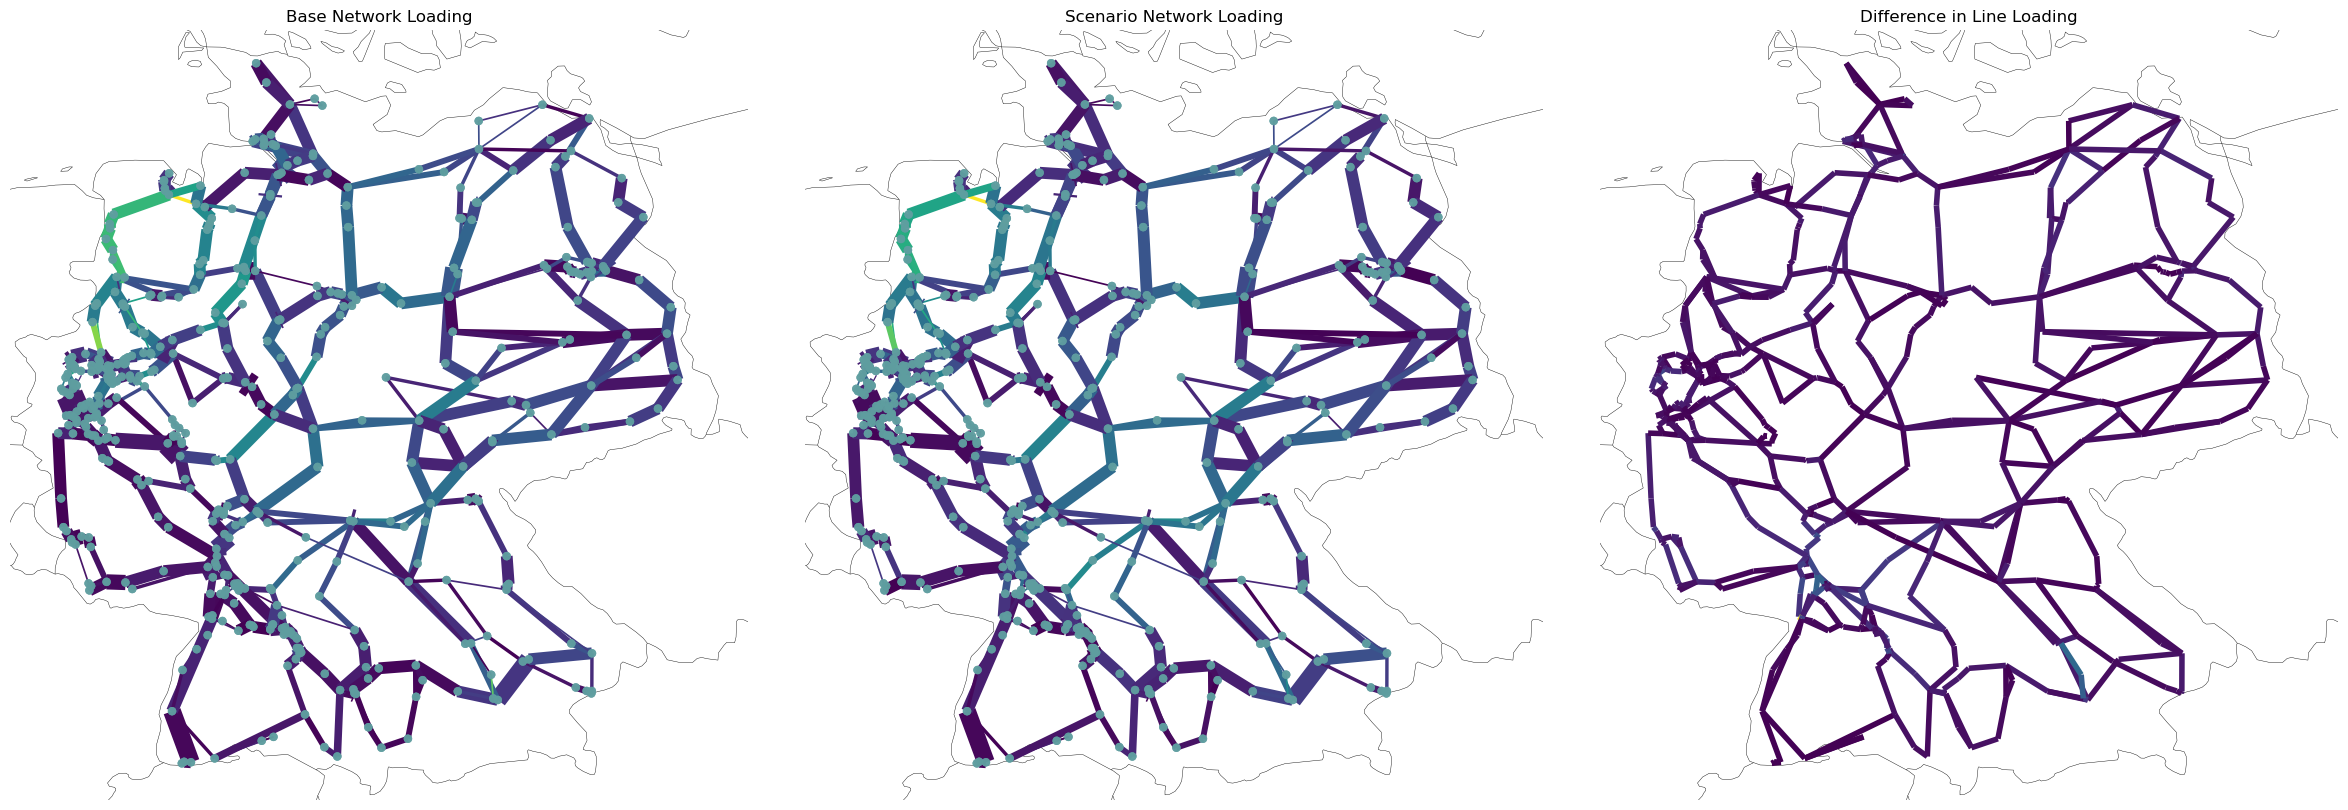

In [48]:
snapshot = n_base.snapshots[8]

bus_size_factor = 1e9
branch_width_factor = 400

fig, axes = plt.subplots(1, 3, figsize=(24, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network ---
def plot_network_loading(n, ax, title):
    # Calculate energy balance for bus sizes
    eb = (
        n.statistics.energy_balance(
            groupby=["bus", "carrier"],
            components=["Generator", "Load", "StorageUnit"],
        )
        .groupby(["bus", "carrier"])
        .sum()
    )
    
    # Calculate line loading for the snapshot
    loading = n.lines_t.p0.loc[snapshot] / n.lines.s_nom
    
   
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=eb.abs().sum() / bus_size_factor,
        bus_alpha=0.7,
        line_colors=loading.abs(),
        line_cmap="viridis",  #"viridis"maps high values to yellow and low values to dark colors.
        line_width=n.lines.s_nom / branch_width_factor, # Relate width to capacity
        link_width=n.links.p_nom / branch_width_factor, # Relate width to capacity
    )

# --- Plot Base and Scenario Networks ---
plot_network_loading(n_base, axes[0], "Base Network Loading")
plot_network_loading(n_scenario, axes[1], "Scenario Network Loading")

if (n_base.lines.s_nom != n_scenario.lines.s_nom).any():
    print("Warning: Line capacities differ between base and scenario. Difference plot may be misleading.")

# --- Plot Difference ---
loading_base = n_base.lines_t.p0.loc[snapshot] / n_base.lines.s_nom
loading_scenario = n_scenario.lines_t.p0.loc[snapshot] / n_scenario.lines.s_nom
loading_diff = (loading_scenario - loading_base).abs()

print(loading_diff)

n_base.plot(
    ax=axes[2], 
    geomap=True, 
    line_width = 4,
    link_width = 4,
    line_colors=loading_diff, 
    title="Difference in Line Loading",
    bus_sizes=0, # Keep buses small for difference plot
)


plt.tight_layout()
plt.show()

##### Load Comparison 

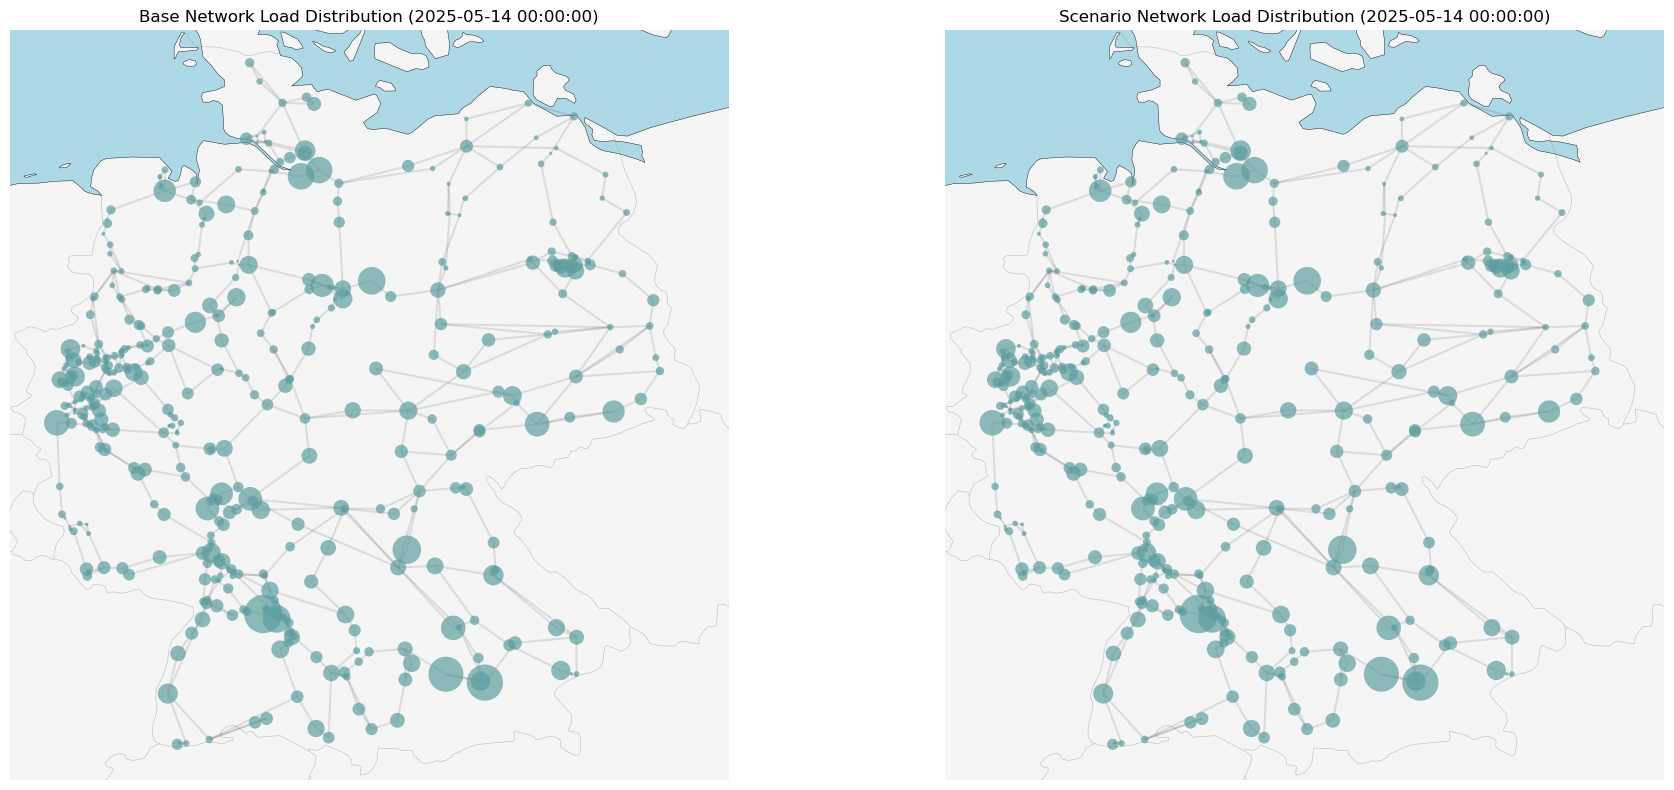

In [49]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 8),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

def plot_load_distribution(n, ax, title):
    snapshot = n.snapshots[0]
    load_distribution = n.loads_t.p_set.loc[snapshot].groupby(n.loads.bus).sum()

    n.plot(
        bus_sizes=(load_distribution/20000),
        ax=ax,
        geomap=True,
        bus_alpha=0.7,
        line_colors='black',
        line_alpha=0.1,
        link_colors='seagreen',
        link_widths=1,
        title=f"{title} Load Distribution ({snapshot})",
        geomap_color=True
    )

plot_load_distribution(n_base, axes[0], "Base Network")
plot_load_distribution(n_scenario, axes[1], "Scenario Network")

plt.tight_layout()
plt.show()


##### Offshore Wind Curtailment

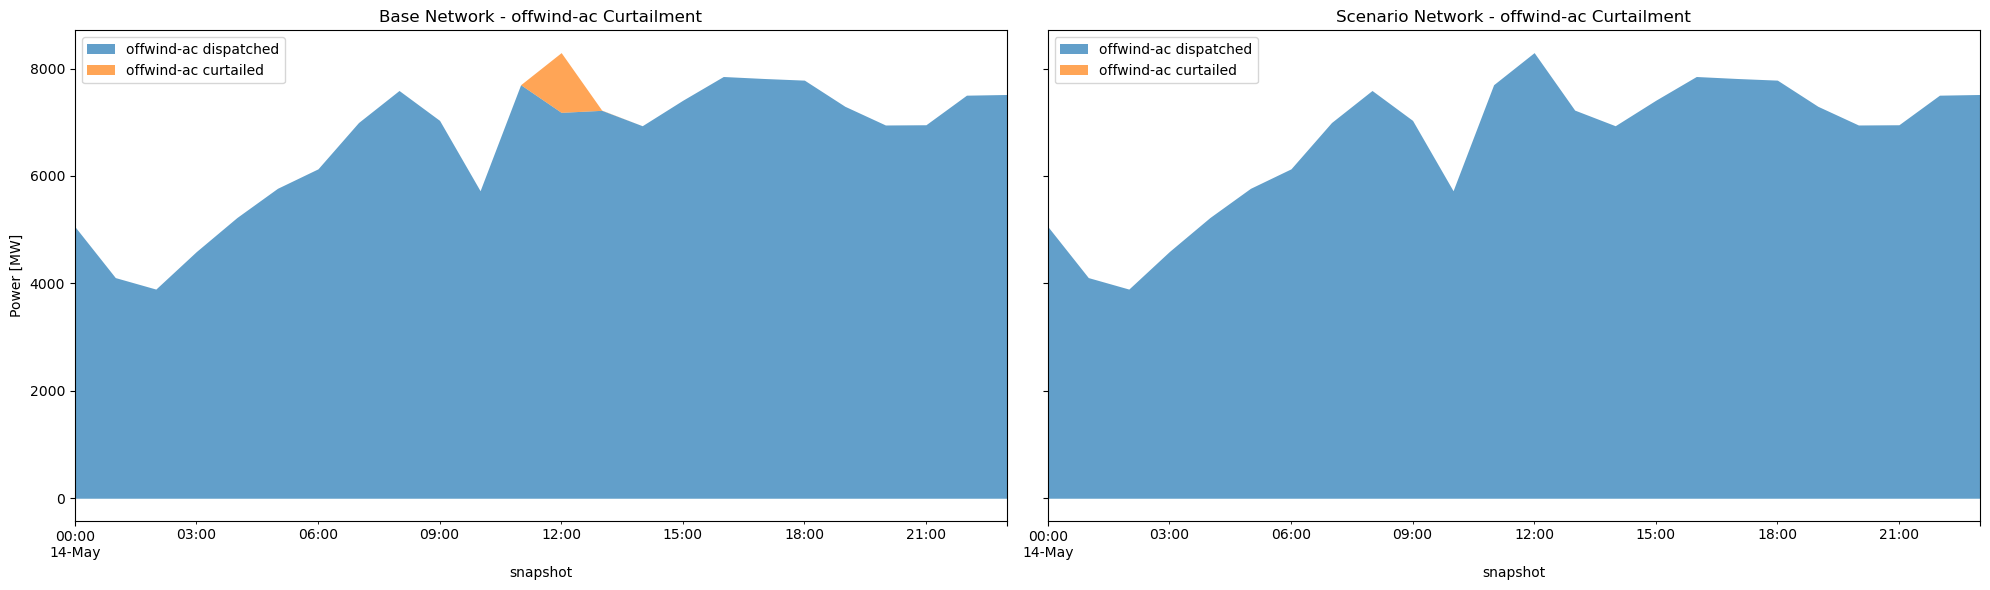

In [50]:
def plot_curtailment(n, carrier, ax):
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    p_dispatched = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed = p_available - p_dispatched
    
    # Correct for any minor negative values from floating point inaccuracies
    p_curtailed[p_curtailed < 0] = 0
    
    df = pd.DataFrame({
        f"{carrier} dispatched": p_dispatched[carrier],
        f"{carrier} curtailed": p_curtailed[carrier]
    })
    
    df.plot(kind="area", ax=ax, lw=0, alpha=0.7)
    ax.set_title(f"{n.name} - {carrier} Curtailment")
    ax.set_ylabel("Power [MW]")

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

plot_curtailment(n_base, "offwind-ac", axes[0])
plot_curtailment(n_scenario, "offwind-ac", axes[1])

plt.tight_layout()
plt.show()

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

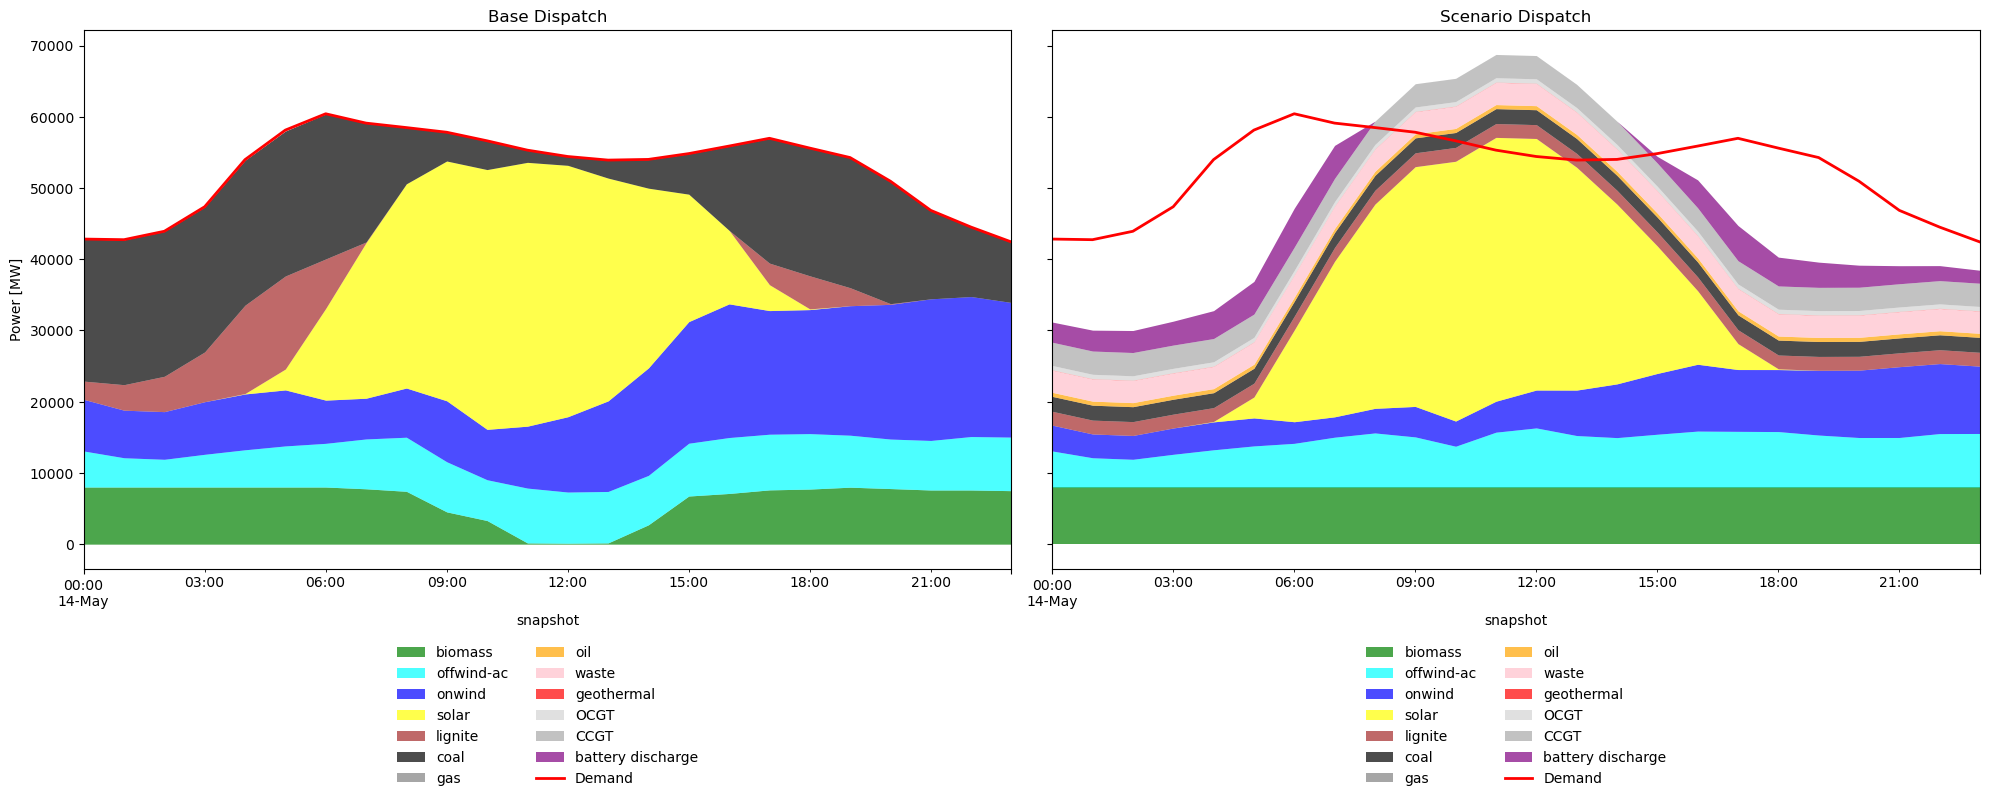

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "gray", "oil": "orange", "waste": "pink", "geothermal": "red",
    "OCGT": "lightgray", "CCGT": "darkgray", "battery discharge": "purple"
}

cols = [
    "biomass", "offwind-ac", "onwind", "solar", "lignite", "coal", "gas", "oil", "waste", "geothermal", "OCGT", "CCGT", "battery discharge"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n_base, axes[0], "Base Dispatch")
plot_dispatch(n_scenario, axes[1], "Scenario Dispatch")

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

##### Total Energy Production by Carrier

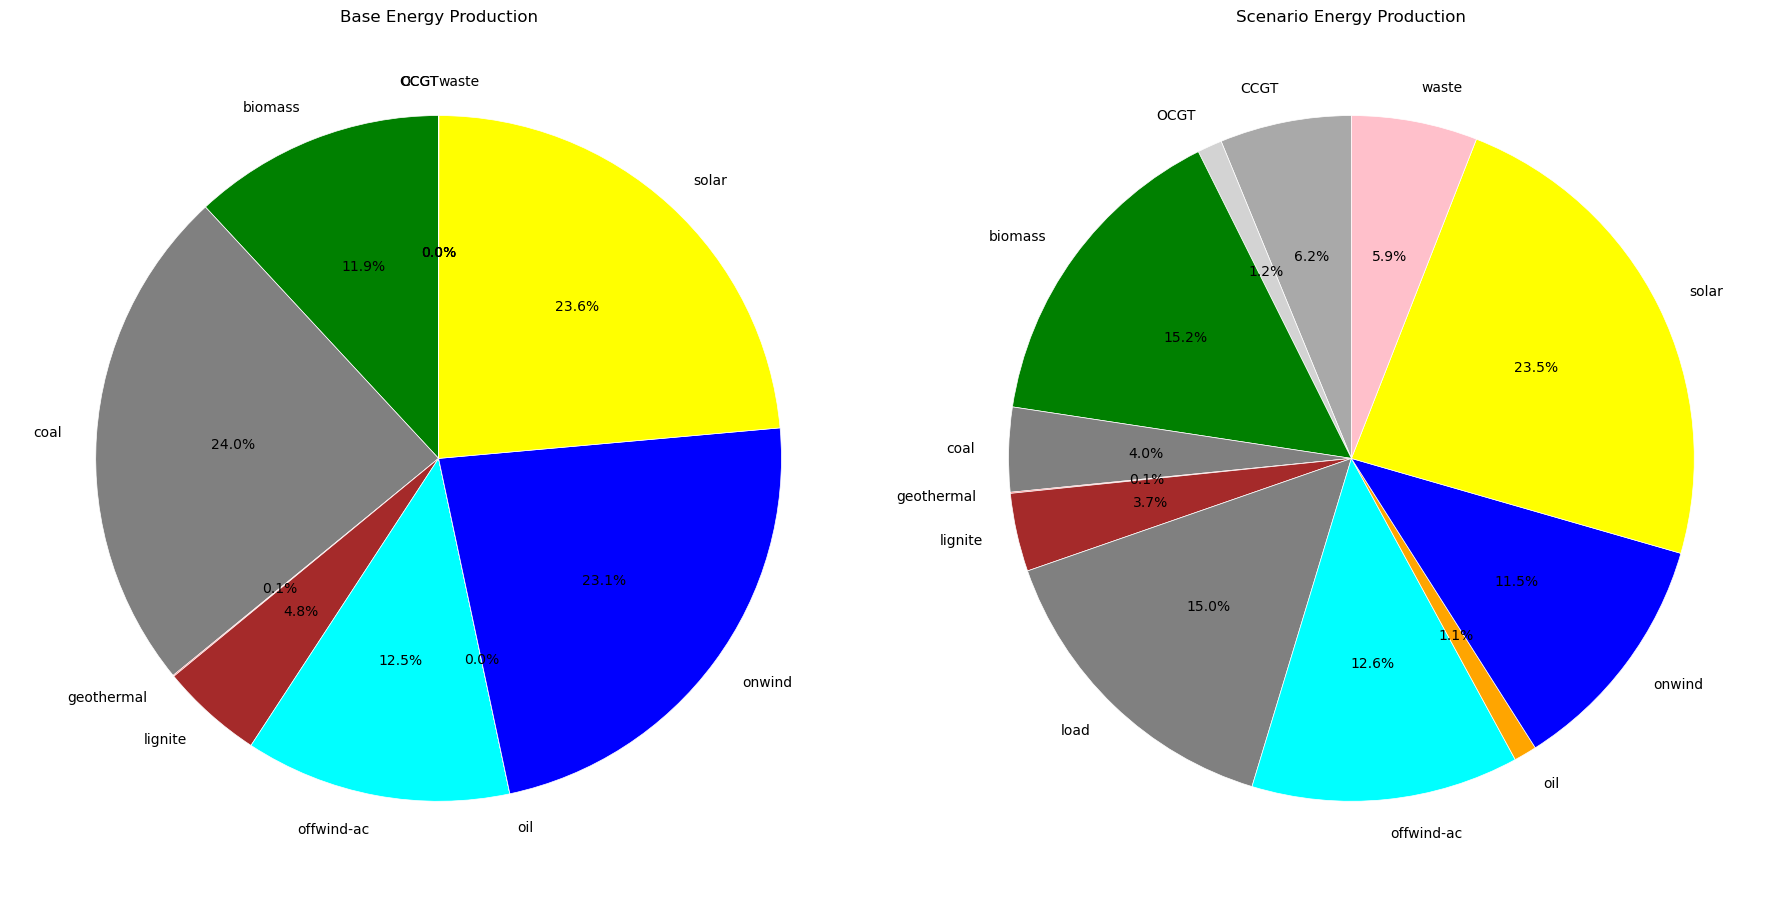

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# --- Define Colors and Order (same as dispatch plot) ---
colors = {
    "biomass": "green", "coal": "gray", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "gray", "oil": "orange", "waste": "pink", "geothermal": "red",
    "OCGT": "lightgray", "CCGT": "darkgray"
}

# --- Helper function for plotting pie chart ---
def plot_energy_pie(p_by_carrier, ax, title):
    energy_total = p_by_carrier.sum()
    # Filter out carriers with zero or negligible energy
    energy_total = energy_total[energy_total > 0.1]
    
    # Get colors for the carriers that are present
    pie_colors = [colors.get(carrier, "grey") for carrier in energy_total.index]

    energy_total.plot(
        kind="pie", 
        ax=ax, 
        autopct='%1.1f%%', 
        startangle=90, 
        title=title,
        colors=pie_colors,
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'} # Add white borders for clarity
    )
    ax.set_ylabel("")

# --- Calculate energy production for each scenario ---
p_by_carrier_base = n_base.generators_t.p.T.groupby(n_base.generators.carrier).sum().T
p_by_carrier_scenario = n_scenario.generators_t.p.T.groupby(n_scenario.generators.carrier).sum().T


# --- Plotting ---
plot_energy_pie(p_by_carrier_base, axes[0], "Base Energy Production")
plot_energy_pie(p_by_carrier_scenario, axes[1], "Scenario Energy Production")


plt.tight_layout()
plt.show()

### 4.3 Energy Balance


##### Unserved Energy Analysis


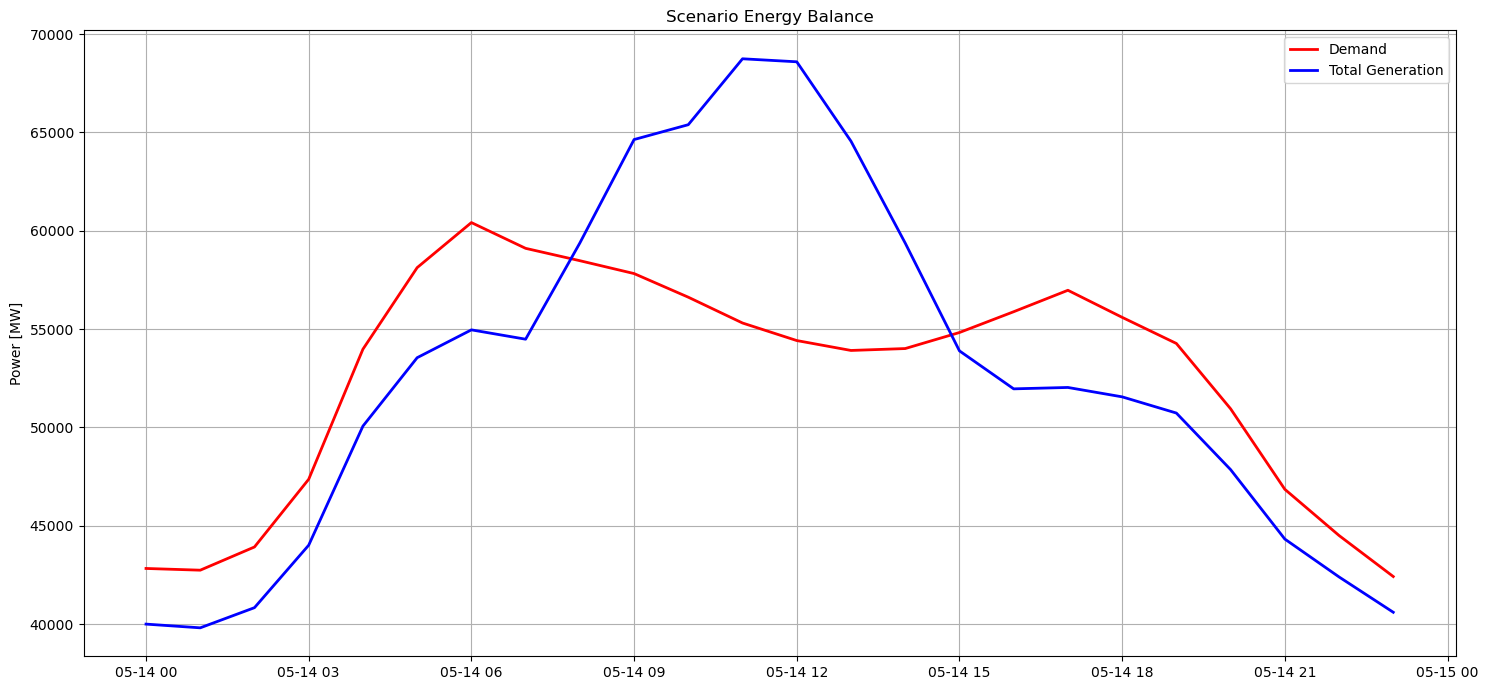

In [57]:
# --- Get Data ---
# Total generation from power plants
total_generation = p_by_carrier_scenario.sum(axis=1)

# Power consumed by Link components
link_dispatch = n_scenario.links_t.p0.T.groupby(n_scenario.links.carrier).sum().T
link_dispatch = link_dispatch.loc[:, (link_dispatch.abs().sum() > 0.1)]

# Isolate battery charging and discharging
battery_charge = link_dispatch['battery charger'] if 'battery charger' in link_dispatch else pd.Series(0, index=link_dispatch.index)
# Discharging is negative from the link's perspective, so we make it positive
battery_discharge = -link_dispatch['battery discharger'] if 'battery discharger' in link_dispatch else pd.Series(0, index=link_dispatch.index)

# Electricity demand
demand = n_scenario.loads_t.p_set.sum(axis=1)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(15, 7))

# Plot Demand and Generation as lines
ax.plot(demand.index, demand, color='red', lw=2, label='Demand')
ax.plot(total_generation.index, total_generation, color='blue', lw=2, label='Total Generation')


# --- Final Touches ---
ax.set_title('Scenario Energy Balance')
ax.set_ylabel('Power [MW]')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [58]:
# Build an electricity-system balance per bus and snapshot.
def _group_sum(df, labels):
    if df.empty:
        return pd.DataFrame(index=n_scenario.snapshots)
    return df.T.groupby(labels).sum().T

bus_balance = _group_sum(n_scenario.generators_t.p, n_scenario.generators.bus)
bus_balance = bus_balance.add(-_group_sum(n_scenario.loads_t.p_set, n_scenario.loads.bus), fill_value=0)

if not n_scenario.storage_units.empty:
    bus_balance = bus_balance.add(_group_sum(n_scenario.storage_units_t.p, n_scenario.storage_units.bus), fill_value=0)

if not n_scenario.stores.empty:
    bus_balance = bus_balance.add(_group_sum(n_scenario.stores_t.p, n_scenario.stores.bus), fill_value=0)

if not n_scenario.links.empty:
    bus_balance = bus_balance.add(-_group_sum(n_scenario.links_t.p0, n_scenario.links.bus0), fill_value=0)
    bus_balance = bus_balance.add(-_group_sum(n_scenario.links_t.p1, n_scenario.links.bus1), fill_value=0)

if not n_scenario.lines.empty:
    bus_balance = bus_balance.add(-_group_sum(n_scenario.lines_t.p0, n_scenario.lines.bus0), fill_value=0)
    bus_balance = bus_balance.add(-_group_sum(n_scenario.lines_t.p1, n_scenario.lines.bus1), fill_value=0)

if not n_scenario.transformers.empty:
    bus_balance = bus_balance.add(-_group_sum(n_scenario.transformers_t.p0, n_scenario.transformers.bus0), fill_value=0)
    bus_balance = bus_balance.add(-_group_sum(n_scenario.transformers_t.p1, n_scenario.transformers.bus1), fill_value=0)

# Residual balance per hour after summing across all buses.
hourly_residual = bus_balance.sum(axis=1)

# Report absolute and relative size of the mismatch.
total_abs_residual_mwh = hourly_residual.abs().sum()
total_residual_mwh = hourly_residual.sum()
peak_hourly_residual_mw = hourly_residual.abs().max()
relative_residual_pct = 100 * total_abs_residual_mwh / demand.sum()

print("--- Full Bus Balance Check (Scenario) ---")
print(f"Total absolute residual: {total_abs_residual_mwh:,.2f} MWh")
print(f"Net residual over horizon: {total_residual_mwh:,.2f} MWh")
print(f"Peak hourly residual: {peak_hourly_residual_mw:,.2f} MW")
print(f"Residual as share of total demand: {relative_residual_pct:.4f}%")
print("----------------------------------------------------")

if total_abs_residual_mwh < 1 and peak_hourly_residual_mw < 1:
    print("The remaining imbalance is just numerical noise.")
elif relative_residual_pct < 0.1:
    print("The residual is small relative to total demand and can likely be neglected in the overall picture.")
else:
    print("The residual is not negligible and should be investigated further.")

# Optional: show the buses with the largest net residual over the horizon.
bus_residual = bus_balance.sum(axis=0).sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTop buses by net residual over the horizon:")
print(bus_residual.head(10))

--- Full Bus Balance Check (Scenario) ---
Total absolute residual: 0.00 MWh
Net residual over horizon: -0.00 MWh
Peak hourly residual: 0.00 MW
Residual as share of total demand: 0.0000%
----------------------------------------------------
The remaining imbalance is just numerical noise.

Top buses by net residual over the horizon:
DE0 203   -1.048836e-06
DE0 100   -9.114543e-07
DE0 8     -8.976779e-07
DE0 358   -8.269767e-07
DE0 296   -7.831387e-07
DE0 422   -7.555942e-07
DE0 255   -5.638393e-07
DE0 415   -5.300515e-07
DE0 374   -4.884248e-07
DE0 124   -4.417666e-07
dtype: float64


### 4.4 Spatial Distribution of Marginal Prices


In [59]:
#n_scenario.components.buses.static

In [60]:
#n_scenario.buses_t.marginal_price

Highest marginal prices found at: 2025-05-14 05:00:00

Top 10 buses with highest marginal prices:
name
DE0 47     99999.948535
DE0 180    99999.948178
DE0 164    99999.947978
DE0 26     99999.947908
DE0 106    99999.947768
DE0 78     99999.946731
DE0 275    99999.946715
DE0 69     99999.946437
DE0 309    99999.946010
DE0 184    99999.945339
Name: 2025-05-14 05:00:00, dtype: float64


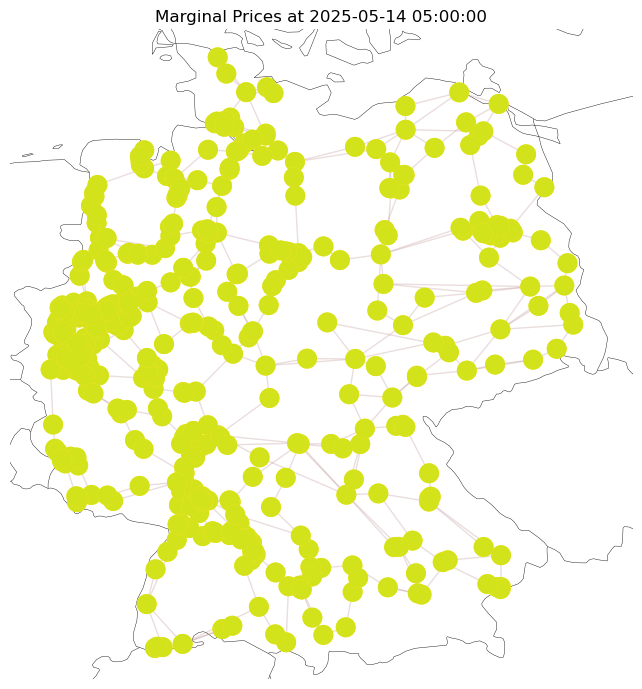

In [66]:
# Find the time with the highest overall marginal price
peak_price_time = n_scenario.buses_t.marginal_price.max(axis=1).idxmax()
peak_prices = n_scenario.buses_t.marginal_price.loc[peak_price_time]

print(f"Highest marginal prices found at: {peak_price_time}")
print("\nTop 10 buses with highest marginal prices:")
print(peak_prices.nlargest(10))

# --- Plot on Map ---
fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw={"projection": ccrs.EqualEarth()}
)

# Plot all buses with a small size
n_scenario.plot(
    ax=ax,
    geomap=True,
    bus_sizes=peak_prices / 5000000, # Size buses by marginal price
    bus_colors=peak_prices,       # Color buses by marginal price
    #cmap='viridis',
    line_widths=1,
    link_widths=1,
    line_alpha=0.3,
    title=f'Marginal Prices at {peak_price_time}'
)

plt.tight_layout()
plt.show()
